## 总数据分布

In [2]:
from pathlib import Path
from collections import Counter
import pandas as pd
import pyarrow.parquet as pq

def distribution_all(SHARD_ROOT):
    parts = sorted(SHARD_ROOT.glob("tissue=*/part.parquet"))
    assert parts, f"No shard files found under: {SHARD_ROOT}"

    print("Found shard files:", len(parts))
    print("Example:", parts[0])
    overall = Counter()
    per_tissue = {}      # tissue -> Counter(label->count)
    tissue_rows = []     # for tissue summary table

    for p in parts:
        tissue = p.parent.name.split("tissue=", 1)[-1]

        # fast row count from parquet metadata (no full read)
        n_rows = int(pq.ParquetFile(str(p)).metadata.num_rows)

        # read only label column (fast)
        df = pd.read_parquet(p, columns=["label"])
        vc = df["label"].value_counts()
        c = Counter(vc.to_dict())

        overall.update(c)
        per_tissue[tissue] = c

        tissue_rows.append({
            "tissue": tissue,
            "n_rows": n_rows,
            "n_classes": int(df["label"].nunique()),
        })

    # ---- Overall distribution ----
    overall_df = (
        pd.DataFrame([{"label": k, "count": v} for k, v in overall.items()])
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )
    total_cells = int(overall_df["count"].sum())
    overall_df["pct"] = (overall_df["count"] / max(1, total_cells) * 100.0).round(3)

    print("\n--- Overall Class Distribution (Aggregated) ---")
    print("Total Cells Across All Slides:", total_cells)
    display(overall_df)

    # ---- Tissue summary ----
    tissue_df = (
        pd.DataFrame(tissue_rows)
        .sort_values("n_rows", ascending=False)
        .reset_index(drop=True)
    )

    print("\n--- Tissue Summary (largest tissues first) ---")
    display(tissue_df)

    # ---- Tissue x label count matrix ----
    all_labels = overall_df["label"].tolist()  # order by global frequency
    mat = []
    for t in tissue_df["tissue"]:
        c = per_tissue.get(t, Counter())
        mat.append([int(c.get(lbl, 0)) for lbl in all_labels])

    tissue_label_df = pd.DataFrame(mat, columns=all_labels)
    tissue_label_df.insert(0, "tissue", tissue_df["tissue"].values)
    tissue_label_df.insert(1, "n_rows", tissue_df["n_rows"].values)

    print("\n--- Tissue x Label Count Matrix (first 10 tissues, first 20 labels) ---")
    display(tissue_label_df.iloc[:10, :min(2 + 20, tissue_label_df.shape[1])])

    # ---- Tissue x Top-K label percentages ----
    top_k = 23
    top_labels = overall_df["label"].head(top_k).tolist()
    tissue_top_pct = tissue_label_df[["tissue", "n_rows"] + top_labels].copy()
    for lbl in top_labels:
        tissue_top_pct[lbl] = (tissue_top_pct[lbl] / tissue_top_pct["n_rows"] * 100.0).round(3)

    print(f"\n--- Tissue x Top-{top_k} Labels (% of tissue) ---")
    display(tissue_top_pct)

    # ---- Save summaries ----
    OUT_DIR = Path("/hpc/group/jilab/rz179/MorphPT_MOE/prepared/analysis_summaries")
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    overall_df.to_csv(OUT_DIR / "overall_label_distribution.csv", index=False)
    tissue_df.to_csv(OUT_DIR / "tissue_summary.csv", index=False)
    tissue_label_df.to_csv(OUT_DIR / "tissue_by_label_counts.csv", index=False)
    tissue_top_pct.to_csv(OUT_DIR / f"tissue_top{top_k}_label_pct.csv", index=False)

    print("\nSaved CSV summaries to:", OUT_DIR)

    return per_tissue,overall_df,tissue_df,tissue_label_df

def analyze_label_distribution(
    label: str,
    per_tissue: dict,
    tissue_df: pd.DataFrame,
    out_dir: Path | None = None,
    top_n: int | None = 20,
):
    """
    Analyze where a given label appears across tissues.

    Returns a DataFrame with:
      - count_in_tissue: # of this label in that tissue
      - pct_of_label: share of this label coming from that tissue (sums to 100)
      - pct_within_tissue: share of that tissue that is this label
    """
    if "tissue" not in tissue_df.columns or "n_rows" not in tissue_df.columns:
        raise ValueError("tissue_df must contain columns: tissue, n_rows")

    rows = []
    for t in tissue_df["tissue"].tolist():
        c = per_tissue.get(t, Counter())
        cnt = int(c.get(label, 0))
        n_rows = int(tissue_df.loc[tissue_df["tissue"] == t, "n_rows"].iloc[0])
        rows.append({"tissue": t, "n_rows": n_rows, "count_in_tissue": cnt})

    df = pd.DataFrame(rows)
    total_label = int(df["count_in_tissue"].sum())

    df["pct_of_label"] = (
        df["count_in_tissue"] / max(1, total_label) * 100.0
    ).round(3)

    df["pct_within_tissue"] = (
        df["count_in_tissue"] / df["n_rows"].clip(lower=1) * 100.0
    ).round(3)

    df = df.sort_values("count_in_tissue", ascending=False).reset_index(drop=True)

    print(f"\n=== Label distribution for: {label} ===")
    print("Total cells of this label across all tissues:", total_label)

    view = df if top_n is None else df.head(int(top_n))
    display(view)

    if out_dir is not None:
        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        safe_label = "".join(ch if ch.isalnum() or ch in "._-" else "_" for ch in label)
        out_path = out_dir / f"label_{safe_label}_by_tissue.csv"
        df.to_csv(out_path, index=False)
        print("Saved:", out_path)

    return df


In [3]:
SHARD_ROOT = Path("/hpc/group/jilab/rz179/MorphPT_MOE/prepared/shards_multiview_parquet")
per_tissue, overall_df,tissue_df,tissue_label_df = distribution_all(SHARD_ROOT)

Found shard files: 34
Example: /hpc/group/jilab/rz179/MorphPT_MOE/prepared/shards_multiview_parquet/tissue=Xenium_Preview_Human_Lung_Cancer/part.parquet

--- Overall Class Distribution (Aggregated) ---
Total Cells Across All Slides: 9545565


,label,count,pct
0,Epithelial cells,1951680,20.446
1,T cells,1319052,13.818
2,Myeloid cells,1309279,13.716
3,B cells,1089992,11.419
4,Fibroblasts,951877,9.972
5,Endothelial cells,631039,6.611
6,Stem and progenitor cells,626997,6.568
7,Smooth muscle cells,417510,4.374
8,Breast cancer cells,316275,3.313
9,NK cells,192502,2.017



--- Tissue Summary (largest tissues first) ---


,tissue,n_rows,n_classes
0,Xenium_V1_hTonsil_reactive_follicular_hyperplasia,1229583,8
1,Xenium_V1_hTonsil_follicular_lymphoid_hyperplasia,746476,8
2,Xenium_V1_FFPE_Human_Breast_IDC_Big_1,731465,8
3,Xenium_V1_FFPE_Human_Breast_IDC_Big_2,709730,8
4,Xenium_human_Lymph_Node_FFPE,662505,7
5,Xenium_V1_FFPE_Human_Breast_IDC_With_Addon,536920,9
6,Xenium_V1_FFPE_Human_Breast_IDC,520752,9
7,Xenium_V1_hColon_Cancer_Add_on,495994,5
8,Xenium_V1_hColon_Cancer_Base,491489,6
9,Xenium_Preview_Human_Lung_Cancer,447257,10



--- Tissue x Label Count Matrix (first 10 tissues, first 20 labels) ---


,tissue,n_rows,Epithelial cells,T cells,Myeloid cells,B cells,Fibroblasts,Endothelial cells,Stem and progenitor cells,Smooth muscle cells,...,Ovary cancer cells,Colon cancer cells,Skin cancer cells,Lung cancer cells,Stromal cells,Pancreas cancer cells,Oligodendrocytes,Pericytes,Neurons,Adipocytes
0,Xenium_V1_hTonsil_reactive_follicular_hyperplasia,1229583,3736,316098,212323,382955,60943,98059,0,60721,...,0,0,0,0,0,0,0,0,0,0
1,Xenium_V1_hTonsil_follicular_lymphoid_hyperplasia,746476,1077,209436,100462,251854,47743,70567,0,55995,...,0,0,0,0,0,0,0,0,0,0
2,Xenium_V1_FFPE_Human_Breast_IDC_Big_1,731465,243586,22601,122306,0,169935,26557,0,20740,...,0,0,0,0,0,0,0,0,0,0
3,Xenium_V1_FFPE_Human_Breast_IDC_Big_2,709730,245078,28606,106977,0,176600,16051,0,23815,...,0,0,0,0,0,0,0,0,0,0
4,Xenium_human_Lymph_Node_FFPE,662505,0,207910,95555,158464,0,118698,24176,0,...,0,0,0,0,57205,0,0,0,0,0
5,Xenium_V1_FFPE_Human_Breast_IDC_With_Addon,536920,324679,35527,44357,16537,74753,18889,0,12739,...,0,0,0,0,0,0,0,0,0,843
6,Xenium_V1_FFPE_Human_Breast_IDC,520752,303284,34560,43939,15919,67043,19023,0,12181,...,0,0,0,0,0,0,0,0,0,1263
7,Xenium_V1_hColon_Cancer_Add_on,495994,0,50601,43856,27483,0,0,274222,0,...,0,99832,0,0,0,0,0,0,0,0
8,Xenium_V1_hColon_Cancer_Base,491489,12055,68995,38472,29827,0,0,265932,0,...,0,76208,0,0,0,0,0,0,0,0
9,Xenium_Preview_Human_Lung_Cancer,447257,110128,46236,119565,11643,66218,44793,0,17777,...,0,0,0,8855,0,0,0,10909,0,0



--- Tissue x Top-23 Labels (% of tissue) ---


,tissue,n_rows,Epithelial cells,T cells,Myeloid cells,B cells,Fibroblasts,Endothelial cells,Stem and progenitor cells,Smooth muscle cells,...,Lung cancer cells,Stromal cells,Pancreas cancer cells,Oligodendrocytes,Pericytes,Neurons,Adipocytes,Liver cancer cells,Microglia,Astrocytes
0,Xenium_V1_hTonsil_reactive_follicular_hyperplasia,1229583,0.304,25.708,17.268,31.145,4.956,7.975,0.000,4.938,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,Xenium_V1_hTonsil_follicular_lymphoid_hyperplasia,746476,0.144,28.057,13.458,33.739,6.396,9.453,0.000,7.501,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,Xenium_V1_FFPE_Human_Breast_IDC_Big_1,731465,33.301,3.090,16.721,0.000,23.232,3.631,0.000,2.835,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,Xenium_V1_FFPE_Human_Breast_IDC_Big_2,709730,34.531,4.031,15.073,0.000,24.883,2.262,0.000,3.356,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,Xenium_human_Lymph_Node_FFPE,662505,0.000,31.382,14.423,23.919,0.000,17.917,3.649,0.000,...,0.000,8.635,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
5,Xenium_V1_FFPE_Human_Breast_IDC_With_Addon,536920,60.471,6.617,8.261,3.080,13.923,3.518,0.000,2.373,...,0.000,0.000,0.000,0.000,0.000,0.000,0.157,0.000,0.000,0.000
6,Xenium_V1_FFPE_Human_Breast_IDC,520752,58.240,6.637,8.438,3.057,12.874,3.653,0.000,2.339,...,0.000,0.000,0.000,0.000,0.000,0.000,0.243,0.000,0.000,0.000
7,Xenium_V1_hColon_Cancer_Add_on,495994,0.000,10.202,8.842,5.541,0.000,0.000,55.287,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
8,Xenium_V1_hColon_Cancer_Base,491489,2.453,14.038,7.828,6.069,0.000,0.000,54.107,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
9,Xenium_Preview_Human_Lung_Cancer,447257,24.623,10.338,26.733,2.603,14.805,10.015,0.000,3.975,...,1.980,0.000,0.000,0.000,2.439,0.000,0.000,0.000,0.000,0.000



Saved CSV summaries to: /hpc/group/jilab/rz179/MorphPT_MOE/prepared/analysis_summaries


In [ ]:
label = "Adipocytes"  
cols = ["tissue", "n_rows", label]
tmp = tissue_label_df[cols].copy()
tmp["pct_in_tissue"] = (tmp[label] / tmp["n_rows"] * 100.0).round(3)
tmp = tmp.sort_values(label, ascending=False)
display(tmp.head(20))

,tissue,n_rows,Adipocytes,pct_in_tissue
12,Xenium_V1_FFPE_Human_Breast_ILC,269870,4220,1.564
14,Xenium_V1_FFPE_Human_Breast_ILC_With_Addon,239173,4107,1.717
6,Xenium_V1_FFPE_Human_Breast_IDC,520752,1263,0.243
5,Xenium_V1_FFPE_Human_Breast_IDC_With_Addon,536920,843,0.157
1,Xenium_V1_hTonsil_follicular_lymphoid_hyperplasia,746476,0,0.000
0,Xenium_V1_hTonsil_reactive_follicular_hyperplasia,1229583,0,0.000
4,Xenium_human_Lymph_Node_FFPE,662505,0,0.000
7,Xenium_V1_hColon_Cancer_Add_on,495994,0,0.000
3,Xenium_V1_FFPE_Human_Breast_IDC_Big_2,709730,0,0.000
2,Xenium_V1_FFPE_Human_Breast_IDC_Big_1,731465,0,0.000


In [7]:
label = "Breast cancer cells"  
cols = ["tissue", "n_rows", label]
tmp = tissue_label_df[cols].copy()
tmp["pct_in_tissue"] = (tmp[label] / tmp["n_rows"] * 100.0).round(3)
tmp = tmp.sort_values(label, ascending=False)
display(tmp.head(7))

,tissue,n_rows,Breast cancer cells,pct_in_tissue
2,Xenium_V1_FFPE_Human_Breast_IDC_Big_1,731465,108980,14.899
3,Xenium_V1_FFPE_Human_Breast_IDC_Big_2,709730,97096,13.681
12,Xenium_V1_FFPE_Human_Breast_ILC,269870,40405,14.972
14,Xenium_V1_FFPE_Human_Breast_ILC_With_Addon,239173,37658,15.745
6,Xenium_V1_FFPE_Human_Breast_IDC,520752,23540,4.520
5,Xenium_V1_FFPE_Human_Breast_IDC_With_Addon,536920,8596,1.601
1,Xenium_V1_hTonsil_follicular_lymphoid_hyperplasia,746476,0,0.000


In [5]:
label = "Epithelial cells"  
cols = ["tissue", "n_rows", label]
tmp = tissue_label_df[cols].copy()
tmp["pct_in_tissue"] = (tmp[label] / tmp["n_rows"] * 100.0).round(3)
tmp = tmp.sort_values(label, ascending=False)
display(tmp.head(20))

,tissue,n_rows,Epithelial cells,pct_in_tissue
5,Xenium_V1_FFPE_Human_Breast_IDC_With_Addon,536920,324679,60.471
6,Xenium_V1_FFPE_Human_Breast_IDC,520752,303284,58.240
3,Xenium_V1_FFPE_Human_Breast_IDC_Big_2,709730,245078,34.531
2,Xenium_V1_FFPE_Human_Breast_IDC_Big_1,731465,243586,33.301
9,Xenium_Preview_Human_Lung_Cancer,447257,110128,24.623
17,Xenium_V1_hLiver_nondiseased,154299,100483,65.122
12,Xenium_V1_FFPE_Human_Breast_ILC,269870,100331,37.178
19,Xenium_V1_hLiver_cancer,147592,71895,48.712
16,Xenium_V1_hColon_Non_diseased_Add_on,177325,65595,36.991
14,Xenium_V1_FFPE_Human_Breast_ILC_With_Addon,239173,61666,25.783


In [7]:
import pandas as pd
df = pd.read_parquet("/hpc/group/jilab/rz179/MorphPT_MOE/prepared/small_balanced.parquet")
print(df.dtypes)

cell_id           object
tissue            object
x_centroid       float32
y_centroid       float32
label             object
img_path_2p5x     object
img_path_10x      object
meta_csv_2p5x     object
meta_csv_10x      object
spatial_csv       object
dtype: object


## 
Running Script: /hpc/group/jilab/rz179/MorphPT_MOE/data/sample_small_balanced.py
Labels (after filters): 19
Example probs: [('Adipocytes', 0.9584970765839165), ('Astrocytes', 1.0), ('B cells', 0.009174379261499168), ('Cardiac muscle cells', 1.0), ('Endothelial cells', 0.01584688109609707)]
Need total top-up: 29017
Wrote: /hpc/group/jilab/rz179/MorphPT_MOE/prepared/small_balanced.parquet
Wrote: /hpc/group/jilab/rz179/MorphPT_MOE/prepared/small_balanced_manifest.json
label
Epithelial cells             10137
Myeloid cells                10123
B cells                      10084
Pericytes                    10036
Fibroblasts                  10026
Stromal cells                10020
Smooth muscle cells          10000
T cells                      10000
NK cells                     10000
Neurons                      10000
Endothelial cells            10000
Adipocytes                   10000
Oligodendrocytes             10000
Stem and progenitor cells    10000
Microglia                     7628
Astrocytes                    7432
Cardiac muscle cells          3472
OPCs                          2488
Erythrocytes                   497
Name: count, dtype: int64
Done.

In [1]:
import timm
print(timm.list_models('*dinov*'))

['vit_7b_patch16_dinov3', 'vit_base_patch14_dinov2', 'vit_base_patch14_reg4_dinov2', 'vit_base_patch16_dinov3', 'vit_base_patch16_dinov3_qkvb', 'vit_giant_patch14_dinov2', 'vit_giant_patch14_reg4_dinov2', 'vit_huge_plus_patch16_dinov3', 'vit_huge_plus_patch16_dinov3_qkvb', 'vit_large_patch14_dinov2', 'vit_large_patch14_reg4_dinov2', 'vit_large_patch16_dinov3', 'vit_large_patch16_dinov3_qkvb', 'vit_small_patch14_dinov2', 'vit_small_patch14_reg4_dinov2', 'vit_small_patch16_dinov3', 'vit_small_patch16_dinov3_qkvb', 'vit_small_plus_patch16_dinov3', 'vit_small_plus_patch16_dinov3_qkvb']


In [3]:
import pandas as pd
import json

# 读取你用来训练的 balanced 数据集
df = pd.read_parquet('/hpc/group/jilab/rz179/MorphPT_MOE/prepared/small_balanced.parquet')

# 获取所有唯一的类别并排序，确保索引稳定
unique_classes = sorted(df['label'].unique())

# 创建新的映射
new_class_to_idx = {cls: i for i, cls in enumerate(unique_classes)}

# 保存为新的 class_map.json
with open('cell_type_idx_without_cancel.json', 'w') as f:
    json.dump(new_class_to_idx, f, indent=4)

print(f"新映射已生成，共 {len(new_class_to_idx)} 类。")
print(new_class_to_idx)

新映射已生成，共 19 类。
{'Adipocytes': 0, 'Astrocytes': 1, 'B cells': 2, 'Cardiac muscle cells': 3, 'Endothelial cells': 4, 'Epithelial cells': 5, 'Erythrocytes': 6, 'Fibroblasts': 7, 'Microglia': 8, 'Myeloid cells': 9, 'NK cells': 10, 'Neurons': 11, 'OPCs': 12, 'Oligodendrocytes': 13, 'Pericytes': 14, 'Smooth muscle cells': 15, 'Stem and progenitor cells': 16, 'Stromal cells': 17, 'T cells': 18}


In [ ]:
import pandas as pd
df = pd.read_parquet("/hpc/group/jilab/rz179/MorphPT_MOE/prepared/shards_multiview_parquet/tissue=Xenium_human_Lung_Cancer_FFPE/part.parquet")
print(df.columns.tolist())
print(df.head())

## Router训练集和测试集分布

In [8]:
import argparse
from pathlib import Path
from collections import defaultdict
import pandas as pd


def count_shards(shard_dir: Path, label_col: str):
    counts = defaultdict(int)
    total = 0
    for p in sorted(shard_dir.glob("*.parquet")):
        df = pd.read_parquet(p, columns=[label_col])
        vc = df[label_col].value_counts()
        for k, v in vc.items():
            counts[k] += int(v)
        total += len(df)
    return counts, total


def print_distribution(title: str, counts: dict, total: int):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)
    print(f"{'Class':<30} {'Count':>12} {'%':>8}")
    print("-" * 55)
    for k in sorted(counts.keys()):
        n = int(counts[k])
        pct = (n / total * 100.0) if total > 0 else 0.0
        print(f"{k:<30} {n:>12,} {pct:>7.2f}%")
    print("-" * 55)
    print(f"{'TOTAL':<30} {total:>12,}")
    if counts:
        vals = list(counts.values())
        print(f"Max/min ratio: {max(vals)}/{min(vals)} = {max(vals)/max(min(vals),1):.1f}x")


def cal_distribution(root, print_router=True, print_test=False, print_expert=False):
    root = Path(root)
    router_dir = root / "router_shards"
    test_dir = root / "test_shards"

    if print_router & router_dir.exists():
        coarse_counts, coarse_total = count_shards(router_dir, "coarse_label")
        print_distribution("ROUTER (coarse)", coarse_counts, coarse_total)

        fine_counts, _ = count_shards(router_dir, "label")
        print_distribution("ROUTER (fine)", fine_counts, coarse_total)

    if print_test & test_dir.exists() :
        test_coarse, test_total = count_shards(test_dir, "coarse_label")
        print_distribution("TEST (coarse)", test_coarse, test_total)

        test_fine, _ = count_shards(test_dir, "label")
        print_distribution("TEST (fine)", test_fine, test_total)

    expert_dirs = sorted([d for d in root.glob("expert_*") if d.is_dir()])
    if print_expert:
        for ed in expert_dirs:
            shard_dir = ed / "shards"
            if not shard_dir.exists():
                continue
            fine_counts, total = count_shards(shard_dir, "label")
            print_distribution(f"EXPERT {ed.name}", fine_counts, total)


In [9]:
root_v5 = "/hpc/group/jilab/rz179/MorphPT_MOE/prepared/splits_v3_seed1337"
cal_distribution(root_v5, True, True)


ROUTER (coarse)
Class                                 Count        %
-------------------------------------------------------
Cancer                              200,037   20.21%
Lymphoid                            201,002   20.31%
Neuroglial                           38,271    3.87%
Stem_Progenitor                     100,000   10.10%
Stromal                              48,000    4.85%
Tissue_Structural                   201,378   20.35%
Vascular                            200,996   20.31%
-------------------------------------------------------
TOTAL                               989,684
Max/min ratio: 201378/38271 = 5.3x

ROUTER (fine)
Class                                 Count        %
-------------------------------------------------------
Adipocytes                            8,178    0.83%
Astrocytes                            5,107    0.52%
B cells                              67,001    6.77%
Breast cancer cells                  32,000    3.23%
Colon cancer cells              

In [3]:
from pathlib import Path
from collections import Counter
import pandas as pd
import pyarrow.parquet as pq

def analyze_router_distribution(ROUTER_ROOT, out_dir=None):
    ROUTER_ROOT = Path(ROUTER_ROOT)
    # Find all parquet files in the flat directory
    files = sorted(ROUTER_ROOT.glob("*.parquet"))
    assert files, f"No parquet files found in: {ROUTER_ROOT}"

    print(f"Found {len(files)} slide files.")
    
    all_data = []
    overall_label = Counter()
    overall_coarse = Counter()
    
    # We'll collect stats for a summary table
    slide_stats = []

    for f in files:
        slide_name = f.stem  # e.g., 'Xenium_human_Lung_Cancer_FFPE'
        
        # 1. Fast metadata read for total rows
        meta = pq.ParquetFile(f).metadata
        n_rows = meta.num_rows
        
        # 2. Read only necessary columns to save memory/time
        # Adjust 'coarse_label' name if your column is named differently
        cols = ["label"]
        available_cols = pq.read_table(f).column_names
        if "coarse_label" in available_cols:
            cols.append("coarse_label")
        
        df = pd.read_parquet(f, columns=cols)
        
        # Update Counters
        lbl_counts = df["label"].value_counts().to_dict()
        overall_label.update(lbl_counts)
        
        coarse_info = "N/A"
        if "coarse_label" in df.columns:
            c_counts = df["coarse_label"].value_counts().to_dict()
            overall_coarse.update(c_counts)
            coarse_info = df["coarse_label"].nunique()

        slide_stats.append({
            "slide": slide_name,
            "total_rows": n_rows,
            "unique_labels": df["label"].nunique(),
            "unique_coarse": coarse_info
        })

    # --- 1. Slide Summary ---
    slide_df = pd.DataFrame(slide_stats).sort_values("total_rows", ascending=False)
    print("\n--- Distribution by Slide ---")
    display(slide_df.head(34))

    # --- 2. Global Label Distribution ---
    label_df = pd.DataFrame([{"label": k, "count": v} for k, v in overall_label.items()])
    label_df = label_df.sort_values("count", ascending=False).reset_index(drop=True)
    label_df["pct"] = (label_df["count"] / label_df["count"].sum() * 100).round(3)
    
    print("\n--- Global Label Distribution (Top 23) ---")
    display(label_df.head(23))

    # --- 3. Global Coarse Label Distribution ---
    if overall_coarse:
        coarse_df = pd.DataFrame([{"coarse_label": k, "count": v} for k, v in overall_coarse.items()])
        coarse_df = coarse_df.sort_values("count", ascending=False).reset_index(drop=True)
        print("\n--- Global Coarse Label Distribution ---")
        display(coarse_df)

    # --- Save Outputs ---
    if out_dir:
        out_path = Path(out_dir)
        out_path.mkdir(parents=True, exist_ok=True)
        slide_df.to_csv(out_path / "slide_summary.csv", index=False)
        label_df.to_csv(out_path / "global_label_dist.csv", index=False)
        print(f"\nSaved summaries to: {out_path}")

    return slide_df, label_df

In [13]:
ROUTER_PATH = "/hpc/group/jilab/rz179/MorphPT_MOE/prepared/splits_v3_seed1337/router_shards"
SAVE_PATH = "/hpc/group/jilab/rz179/MorphPT_MOE/prepared/analysis_summaries/router_v3"

slide_summary, label_summary = analyze_router_distribution(ROUTER_PATH, out_dir=SAVE_PATH)

Found 34 slide files.

--- Distribution by Slide ---


,slide,total_rows,unique_labels,unique_coarse
29,Xenium_V1_hTonsil_reactive_follicular_hyperplasia,111200,8,3
31,Xenium_human_Lymph_Node_FFPE,88798,6,4
12,Xenium_V1_hColon_Cancer_Add_on,68728,5,4
13,Xenium_V1_hColon_Cancer_Base,65239,6,5
2,Xenium_Prime_Ovarian_Cancer_FFPE,56463,8,4
7,Xenium_V1_FFPE_Human_Breast_IDC_Big_1,56441,8,4
8,Xenium_V1_FFPE_Human_Breast_IDC_Big_2,54582,8,4
28,Xenium_V1_hTonsil_follicular_lymphoid_hyperplasia,54229,8,3
0,Xenium_Preview_Human_Lung_Cancer,45476,10,4
6,Xenium_V1_FFPE_Human_Breast_IDC,31930,9,4



--- Global Label Distribution (Top 23) ---


,label,count,pct
0,Stem and progenitor cells,100000,10.104
1,Fibroblasts,85002,8.589
2,Epithelial cells,84999,8.588
3,B cells,67001,6.770
4,NK cells,67001,6.770
5,T cells,67000,6.770
6,Endothelial cells,66999,6.770
7,Myeloid cells,66999,6.770
8,Smooth muscle cells,66998,6.770
9,Stromal cells,48000,4.850



--- Global Coarse Label Distribution ---


,coarse_label,count
0,Tissue_Structural,201378
1,Lymphoid,201002
2,Vascular,200996
3,Cancer,200037
4,Stem_Progenitor,100000
5,Stromal,48000
6,Neuroglial,38271



Saved summaries to: /hpc/group/jilab/rz179/MorphPT_MOE/prepared/analysis_summaries/router_v3


In [4]:
cancer_expert_path = "/hpc/group/jilab/rz179/MorphPT_MOE/prepared/splits_v3_seed1337/expert_Cancer/shards"
cancer_expert_path_SAVE_PATH = "/hpc/group/jilab/rz179/MorphPT_MOE/prepared/analysis_summaries/expert_cancer"

cancer_slide_summary, cancer_label_summary = analyze_router_distribution(cancer_expert_path, out_dir=cancer_expert_path_SAVE_PATH)

Found 17 slide files.

--- Distribution by Slide ---


,slide,total_rows,unique_labels,unique_coarse
1,Xenium_Prime_Ovarian_Cancer_FFPE,10000,1,1
15,Xenium_human_Pancreas_FFPE,10000,1,1
2,Xenium_V1_FFPE_Human_Breast_IDC,10000,1,1
3,Xenium_V1_FFPE_Human_Breast_IDC_Big_1,10000,1,1
4,Xenium_V1_FFPE_Human_Breast_IDC_Big_2,10000,1,1
6,Xenium_V1_FFPE_Human_Breast_ILC,10000,1,1
7,Xenium_V1_FFPE_Human_Breast_ILC_With_Addon,10000,1,1
8,Xenium_V1_hColon_Cancer_Add_on,10000,1,1
9,Xenium_V1_hColon_Cancer_Base,10000,1,1
16,Xeniumranger_V1_hSkin_Melanoma_Add_on,10000,1,1



--- Global Label Distribution (Top 23) ---


,label,count,pct
0,Breast cancer cells,57246,34.972
1,Lung cancer cells,28406,17.354
2,Colon cancer cells,20000,12.218
3,Skin cancer cells,20000,12.218
4,Pancreas cancer cells,20000,12.218
5,Ovary cancer cells,10000,6.109
6,Liver cancer cells,8037,4.910



--- Global Coarse Label Distribution ---


,coarse_label,count
0,Cancer,163689



Saved summaries to: /hpc/group/jilab/rz179/MorphPT_MOE/prepared/analysis_summaries/expert_cancer


In [11]:
ROUTER_PATH = "/hpc/group/jilab/rz179/MorphPT_MOE/prepared/splits_v3_seed1337/val_balanced"
SAVE_PATH = "/hpc/group/jilab/rz179/MorphPT_MOE/prepared/analysis_summaries/val_balanced"

slide_summary, label_summary = analyze_router_distribution(ROUTER_PATH, out_dir=SAVE_PATH)

Found 1 slide files.

--- Distribution by Slide ---


,slide,total_rows,unique_labels,unique_coarse
0,val_balanced,181550,23,7



--- Global Label Distribution (Top 23) ---


,label,count,pct
0,Stem and progenitor cells,30000,16.524
1,Epithelial cells,20538,11.313
2,Myeloid cells,16748,9.225
3,T cells,14629,8.058
4,Oligodendrocytes,13606,7.494
5,B cells,13469,7.419
6,Breast cancer cells,10247,5.644
7,Stromal cells,9540,5.255
8,Fibroblasts,9041,4.980
9,Endothelial cells,8004,4.409



--- Global Coarse Label Distribution ---


,coarse_label,count
0,Cancer,30000
1,Stem_Progenitor,30000
2,Vascular,30000
3,Tissue_Structural,30000
4,Lymphoid,30000
5,Neuroglial,22010
6,Stromal,9540



Saved summaries to: /hpc/group/jilab/rz179/MorphPT_MOE/prepared/analysis_summaries/val_balanced


## Router training dataset vs Orignal full dataset

Comparison plot saved to: /hpc/group/jilab/rz179/MorphPT_MOE/prepared/analysis_summaries/router_sampling_analysis.png


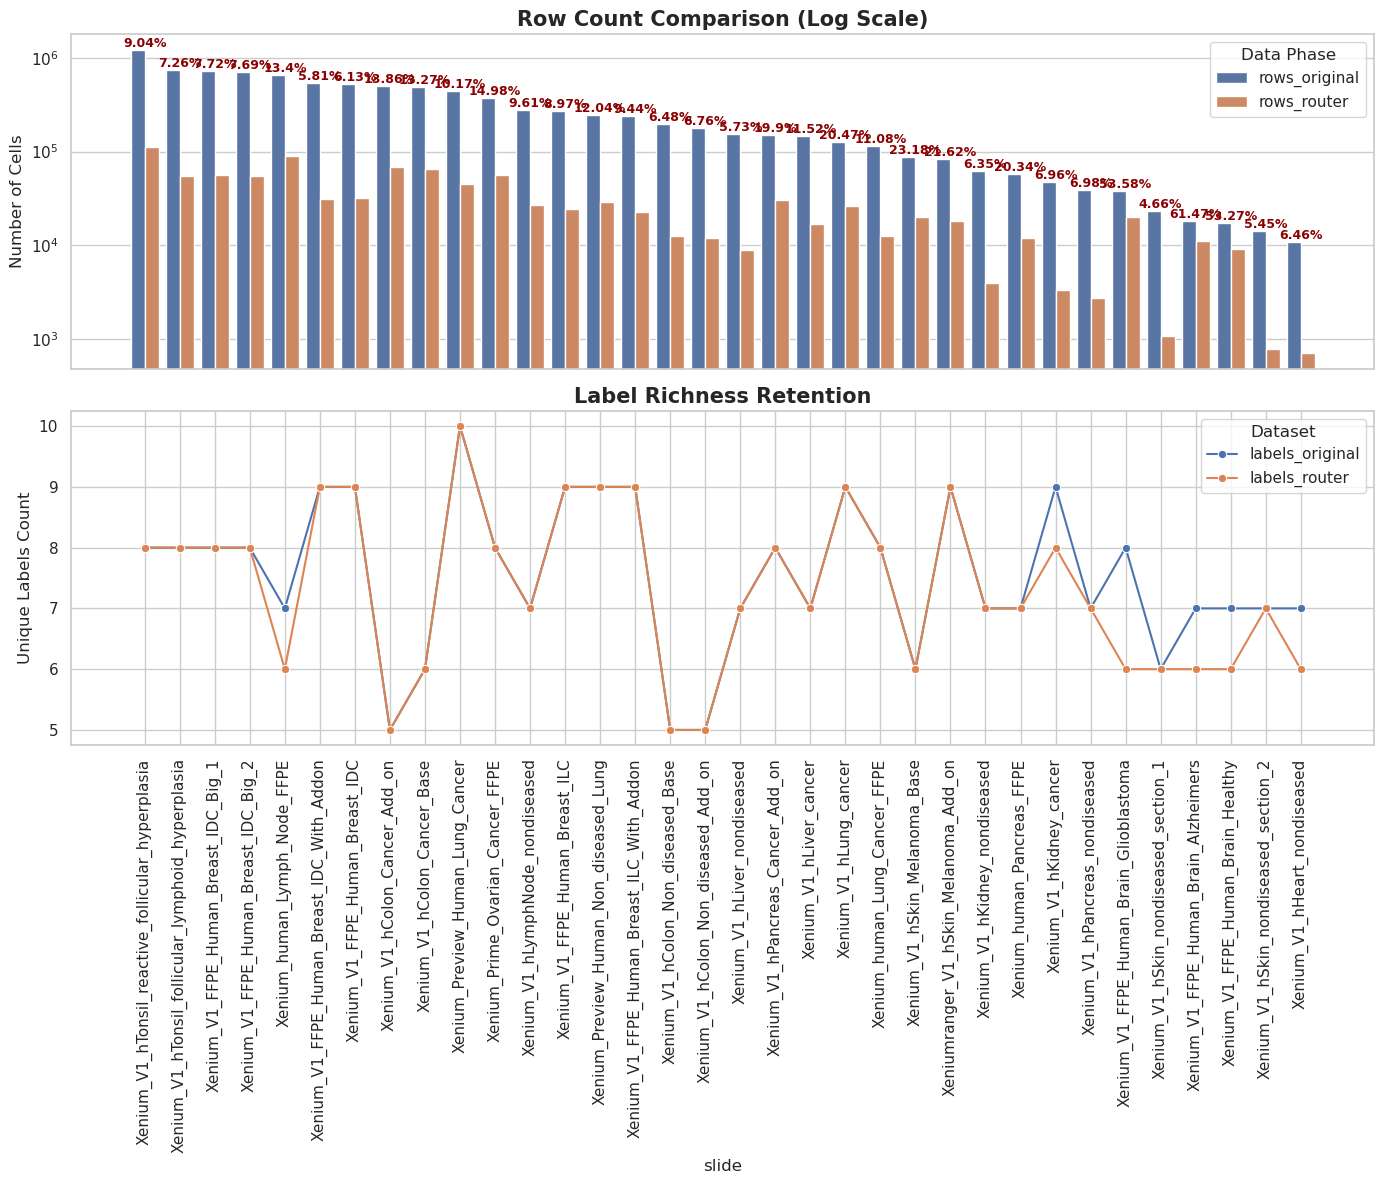


--- Sampling Rate Summary ---
                                            slide  rows_original  rows_router  sampling_rate
            Xenium_V1_FFPE_Human_Brain_Alzheimers          18121        11139          61.47
          Xenium_V1_FFPE_Human_Brain_Glioblastoma          37604        20148          53.58
               Xenium_V1_FFPE_Human_Brain_Healthy          17107         9113          53.27
                    Xenium_V1_hSkin_Melanoma_Base          87476        20275          23.18
            Xeniumranger_V1_hSkin_Melanoma_Add_on          83869        18132          21.62
                           Xenium_V1_hLung_cancer         127803        26167          20.47
                       Xenium_human_Pancreas_FFPE          58186        11837          20.34
                Xenium_V1_hPancreas_Cancer_Add_on         152113        30275          19.90
                 Xenium_Prime_Ovarian_Cancer_FFPE         376908        56463          14.98
                   Xenium_V1_hColon_Can

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. 加载数据
original_path = Path("/hpc/group/jilab/rz179/MorphPT_MOE/prepared/analysis_summaries/tissue_summary.csv")
router_path = Path("/hpc/group/jilab/rz179/MorphPT_MOE/prepared/analysis_summaries/router_v3/slide_summary.csv")

df_orig = pd.read_csv(original_path)
df_router = pd.read_csv(router_path)

# 2. 预处理：统一列名以便合并
# 原始数据列: tissue, n_rows, n_classes
# Router数据列: slide, total_rows, unique_labels, unique_coarse
df_orig = df_orig.rename(columns={"tissue": "slide", "n_rows": "rows_original", "n_classes": "labels_original"})
df_router = df_router.rename(columns={"total_rows": "rows_router", "unique_labels": "labels_router"})

# 合并数据
df_comp = pd.merge(df_orig, df_router, on="slide", how="inner")

# 计算采样比例 (%)
df_comp['sampling_rate'] = (df_comp['rows_router'] / df_comp['rows_original'] * 100).round(2)

# 3. 绘图
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# --- 图A: 数据量对比 (对数坐标轴，因为数据差距极大) ---
df_melted_rows = df_comp.melt(id_vars="slide", value_vars=["rows_original", "rows_router"], 
                              var_name="Dataset", value_name="Count")
sns.barplot(data=df_melted_rows, x="slide", y="Count", hue="Dataset", ax=axes[0])
axes[0].set_yscale("log") # 使用对数坐标
axes[0].set_title("Row Count Comparison (Log Scale)", fontsize=15, fontweight='bold')
axes[0].set_ylabel("Number of Cells")
axes[0].legend(title="Data Phase")

# 在柱状图上方标注采样百分比
for i, rate in enumerate(df_comp['sampling_rate']):
    axes[0].text(i, df_comp.loc[i, 'rows_original'], f"{rate}%", 
                 ha='center', va='bottom', fontsize=9, color='darkred', fontweight='bold')

# --- 图B: 标签数量对比 ---
df_melted_labels = df_comp.melt(id_vars="slide", value_vars=["labels_original", "labels_router"], 
                                var_name="Dataset", value_name="Labels")
sns.lineplot(data=df_melted_labels, x="slide", y="Labels", hue="Dataset", marker="o", ax=axes[1])
axes[1].set_title("Label Richness Retention", fontsize=15, fontweight='bold')
axes[1].set_ylabel("Unique Labels Count")
plt.xticks(rotation=90)

plt.tight_layout()

# 保存图片
out_img = Path("/hpc/group/jilab/rz179/MorphPT_MOE/prepared/analysis_summaries/router_sampling_analysis.png")
plt.savefig(out_img, dpi=300, bbox_inches='tight')
print(f"Comparison plot saved to: {out_img}")
plt.show()

# 4. 输出采样统计摘要
print("\n--- Sampling Rate Summary ---")
print(df_comp[['slide', 'rows_original', 'rows_router', 'sampling_rate']].sort_values('sampling_rate', ascending=False).to_string(index=False))

In [15]:
import pandas as pd
from pathlib import Path
from collections import Counter

def analyze_dropped_labels(per_tissue_orig, router_root):
    """
    对比原始统计数据与Router实际数据，找出丢失的标签
    :param per_tissue_orig: 之前 distribution_all 函数返回的 per_tissue 字典
    :param router_root: Router parquet 文件所在目录
    """
    router_root = Path(router_root)
    results = []

    print(f"{'Slide Name':<50} | {'Status':<10} | {'Dropped Labels (Original Count)':<30}")
    print("-" * 100)

    for slide, orig_counts in per_tissue_orig.items():
        router_file = router_root / f"{slide}.parquet"
        
        if not router_file.exists():
            continue
            
        # 读取 Router 文件中的实际标签
        df_router = pd.read_parquet(router_file, columns=["label"])
        router_labels = set(df_router["label"].unique())
        orig_labels = set(orig_counts.keys())
        
        # 找出原始有但 Router 里没有的
        dropped = orig_labels - router_labels
        
        if dropped:
            # 获取这些丢失标签在原始数据中的具体数量，辅助判断是否因太稀有而被采样刷掉
            dropped_info = [f"{lbl} ({orig_counts[lbl]})" for lbl in dropped]
            status = "⚠️ DROPPED"
            dropped_str = ", ".join(dropped_info)
        else:
            status = "✅ FULL"
            dropped_str = "-"

        print(f"{slide[:50]:<50} | {status:<10} | {dropped_str}")
        
        if dropped:
            for lbl in dropped:
                results.append({
                    "slide": slide,
                    "label": lbl,
                    "original_count": orig_counts[lbl]
                })

    dropped_df = pd.DataFrame(results)
    return dropped_df

# 使用示例
# per_tissue_orig 是你运行第一个函数 distribution_all 返回的第一个变量
ROUTER_PATH = "/hpc/group/jilab/rz179/MorphPT_MOE/prepared/splits_v3_seed1337/router_shards"
dropped_labels_report = analyze_dropped_labels(per_tissue, ROUTER_PATH)

if not dropped_labels_report.empty:
    print("\n--- Summary of Dropped Labels ---")
    display(dropped_labels_report.sort_values("original_count", ascending=False))

Slide Name                                         | Status     | Dropped Labels (Original Count)
----------------------------------------------------------------------------------------------------
Xenium_Preview_Human_Lung_Cancer                   | ✅ FULL     | -
Xenium_Preview_Human_Non_diseased_Lung             | ✅ FULL     | -
Xenium_Prime_Ovarian_Cancer_FFPE                   | ✅ FULL     | -
Xenium_V1_FFPE_Human_Brain_Alzheimers              | ⚠️ DROPPED | OPCs (658)
Xenium_V1_FFPE_Human_Brain_Glioblastoma            | ⚠️ DROPPED | OPCs (1037), Brain cancer cells (2344)
Xenium_V1_FFPE_Human_Brain_Healthy                 | ⚠️ DROPPED | OPCs (793)
Xenium_V1_FFPE_Human_Breast_IDC                    | ✅ FULL     | -
Xenium_V1_FFPE_Human_Breast_IDC_Big_1              | ✅ FULL     | -
Xenium_V1_FFPE_Human_Breast_IDC_Big_2              | ✅ FULL     | -
Xenium_V1_FFPE_Human_Breast_IDC_With_Addon         | ✅ FULL     | -
Xenium_V1_FFPE_Human_Breast_ILC                    | ✅ FULL     | 

,slide,label,original_count
4,Xenium_V1_hHeart_nondiseased,Cardiac muscle cells,3472
2,Xenium_V1_FFPE_Human_Brain_Glioblastoma,Brain cancer cells,2344
5,Xenium_V1_hKidney_cancer,Kidney cancer cells,1128
1,Xenium_V1_FFPE_Human_Brain_Glioblastoma,OPCs,1037
3,Xenium_V1_FFPE_Human_Brain_Healthy,OPCs,793
0,Xenium_V1_FFPE_Human_Brain_Alzheimers,OPCs,658
6,Xenium_human_Lymph_Node_FFPE,Erythrocytes,497


Unified grouped plot saved to: /hpc/group/jilab/rz179/MorphPT_MOE/prepared/analysis_summaries/unified_grouped_distribution.png


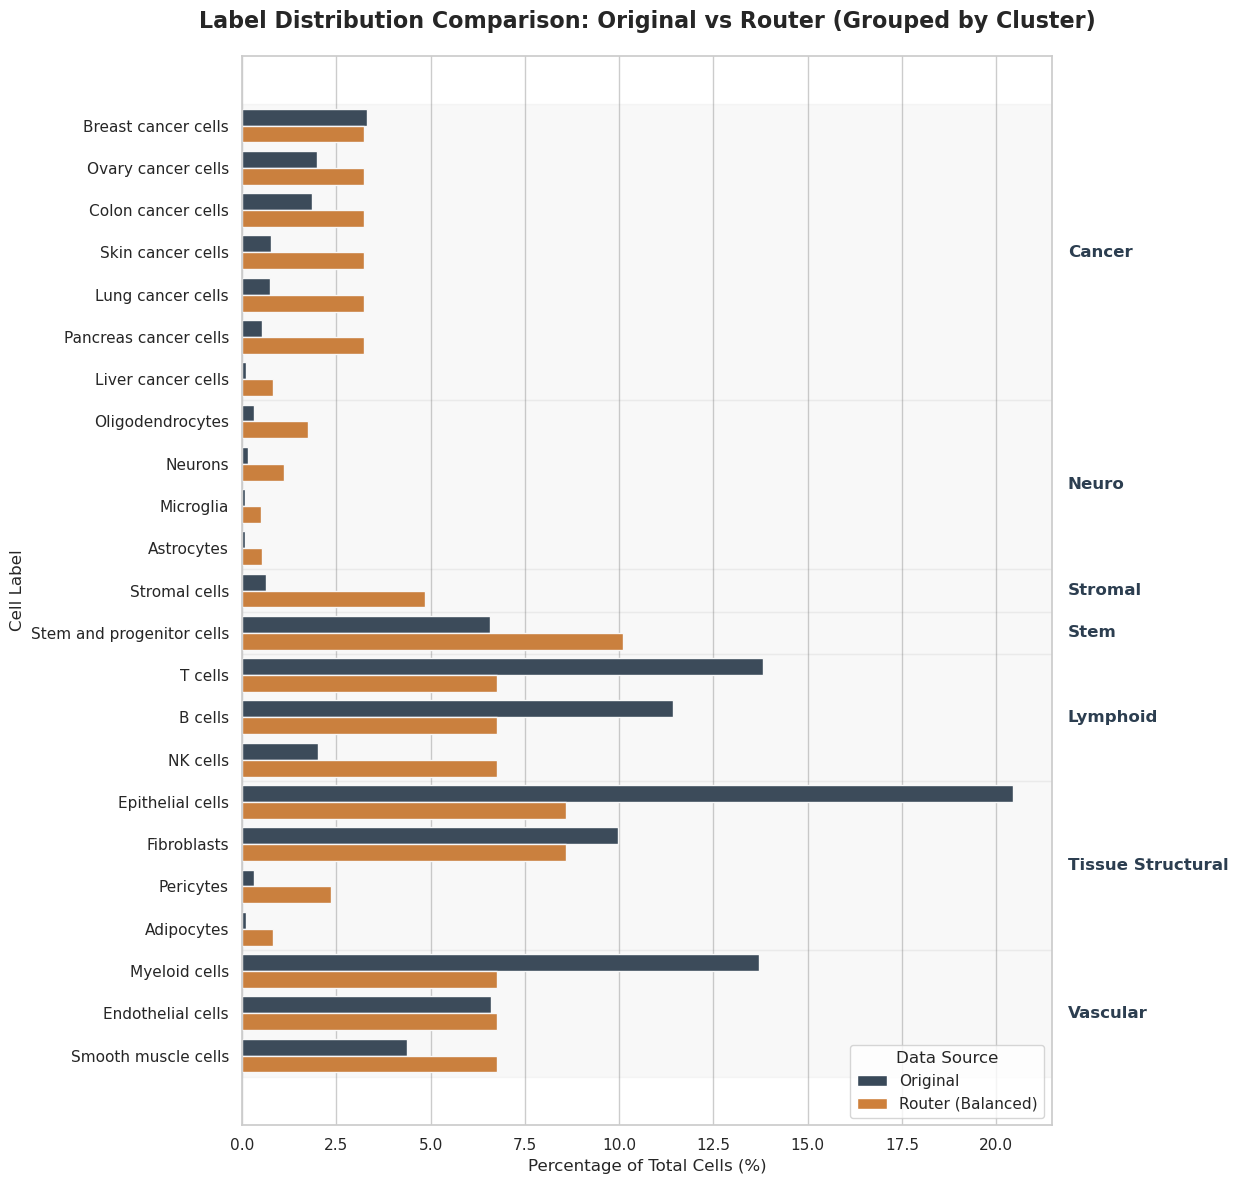

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 1. 加载数据
orig_path = Path("/hpc/group/jilab/rz179/MorphPT_MOE/prepared/analysis_summaries/overall_label_distribution.csv")
router_path = Path("/hpc/group/jilab/rz179/MorphPT_MOE/prepared/analysis_summaries/router_v3/global_label_dist.csv")

df_orig = pd.read_csv(orig_path)
df_router = pd.read_csv(router_path)

# 2. 定义生物学集群排序 (Cluster Group Order)
groups = {
    "Cancer": ["Breast cancer cells", "Ovary cancer cells", "Colon cancer cells", "Skin cancer cells", "Lung cancer cells", "Pancreas cancer cells", "Liver cancer cells"],
    "Neuro": ["Microglia", "Oligodendrocytes", "Astrocytes", "Neurons"],
    "Stromal": ["Stromal cells"],
    "Stem": ["Stem and progenitor cells"],
    "Lymphoid": ["NK cells", "B cells", "T cells"],
    "Tissue Structural": ["Adipocytes", "Epithelial cells", "Pericytes", "Fibroblasts"],
    "Vascular": ["Endothelial cells", "Myeloid cells", "Smooth muscle cells"]
}

# 3. 数据对齐与合并
kept_labels = df_router['label'].unique()
df_orig_filtered = df_orig[df_orig['label'].isin(kept_labels)].copy()

# 标记数据集来源
df_orig_filtered['Dataset'] = 'Original'
df_router['Dataset'] = 'Router (Balanced)'

# 合并数据
df_combined = pd.concat([df_orig_filtered, df_router], ignore_index=True)

# 4. 确定最终的显示顺序 (按 Cluster 排序)
order_cluster = []
for g in ["Cancer", "Neuro", "Stromal", "Stem", "Lymphoid", "Tissue Structural", "Vascular"]:
    group_labels = [l for l in groups[g] if l in kept_labels]
    # 组内按原始丰度降序排列，视觉上更整齐
    sorted_group = df_orig_filtered[df_orig_filtered['label'].isin(group_labels)].sort_values('pct', ascending=False)['label'].tolist()
    order_cluster.extend(sorted_group)

# 5. 绘图
plt.figure(figsize=(14, 12))
sns.set_theme(style="whitegrid")

# 使用 hue 参数将两个数据集的条形图放在一起
ax = sns.barplot(
    data=df_combined,
    y='label',
    x='pct',
    hue='Dataset',
    order=order_cluster,
    palette={'Original': '#34495e', 'Router (Balanced)': '#e67e22'}
)

# 6. 添加集群标注和背景区分
current_y = 0
for group_name in ["Cancer", "Neuro", "Stromal", "Stem", "Lymphoid", "Tissue Structural", "Vascular"]:
    group_len = len([l for l in groups[group_name] if l in kept_labels])
    if group_len > 0:
        midpoint = current_y + (group_len - 1) / 2
        # 在右侧添加集群名称
        plt.text(ax.get_xlim()[1] * 1.02, midpoint, group_name, va='center', fontweight='bold', color='#2c3e50', fontsize=12)
        # 给不同集群添加交替的背景阴影
        plt.axhspan(current_y - 0.5, current_y + group_len - 0.5, color='gray', alpha=0.05)
        current_y += group_len

plt.title("Label Distribution Comparison: Original vs Router (Grouped by Cluster)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Percentage of Total Cells (%)", fontsize=12)
plt.ylabel("Cell Label", fontsize=12)
plt.legend(title="Data Source", loc='lower right', frameon=True)

# 调整布局
plt.tight_layout(rect=[0, 0, 0.9, 1])

# 保存并显示
out_img = Path("/hpc/group/jilab/rz179/MorphPT_MOE/prepared/analysis_summaries/unified_grouped_distribution.png")
plt.savefig(out_img, dpi=300, bbox_inches='tight')
print(f"Unified grouped plot saved to: {out_img}")
plt.show()

## 专家数据集

In [5]:
from pathlib import Path
from collections import Counter
import pandas as pd

def cal_expert_distribution(SHARD_ROOT):
    parts = sorted(SHARD_ROOT.glob("*.parquet"))
    print(f"Found {len(parts)} shard files\n")

    overall = Counter()
    tissue_rows = []

    for p in parts:
        tissue = p.stem
        df = pd.read_parquet(p, columns=["label"])
        vc = df["label"].value_counts()
        overall.update(vc.to_dict())
        tissue_rows.append({"tissue": tissue, "n_rows": len(df), "n_classes": df["label"].nunique()})

    # Overall
    total = sum(overall.values())
    print(f"Total: {total:,}\n")
    print(f"{'Fine Class':<30} {'Count':>8} {'%':>7}")
    print(f"{'─' * 47}")
    for label, cnt in sorted(overall.items(), key=lambda x: -x[1]):
        print(f"{label:<30} {cnt:>8,} {cnt/total*100:>6.1f}%")

    # Per tissue
    print(f"\n{'Tissue':<55} {'Rows':>8} {'Classes':>8}")
    print(f"{'─' * 73}")
    for r in sorted(tissue_rows, key=lambda x: -x["n_rows"]):
        print(f"{r['tissue']:<55} {r['n_rows']:>8,} {r['n_classes']:>8}")

In [ ]:
cancer_root = Path("/hpc/group/jilab/rz179/MorphPT_MOE/prepared/splits_v3_seed1337/expert_Cancer/capped")
cal_expert_distribution(cancer_root)

Found 17 shard files

Total: 118,037

Fine Class                        Count       %
───────────────────────────────────────────────
Lung cancer cells                20,000   16.9%
Breast cancer cells              20,000   16.9%
Colon cancer cells               20,000   16.9%
Pancreas cancer cells            20,000   16.9%
Skin cancer cells                20,000   16.9%
Ovary cancer cells               10,000    8.5%
Liver cancer cells                8,037    6.8%

Tissue                                                      Rows  Classes
─────────────────────────────────────────────────────────────────────────
Xenium_Prime_Ovarian_Cancer_FFPE                          10,000        1
Xenium_V1_hColon_Cancer_Add_on                            10,000        1
Xenium_V1_hColon_Cancer_Base                              10,000        1
Xenium_V1_hPancreas_Cancer_Add_on                         10,000        1
Xenium_V1_hSkin_Melanoma_Base                             10,000        1
Xenium_huma

In [ ]:
lymphoid_root = Path("/hpc/group/jilab/rz179/MorphPT_MOE/prepared/splits_v3_seed1337/expert_Lymphoid/shards")
cal_expert_distribution(lymphoid_root)

Found 31 shard files

Total: 457,325

Fine Class                        Count       %
───────────────────────────────────────────────
T cells                         249,099   54.5%
B cells                         140,709   30.8%
NK cells                         67,517   14.8%

Tissue                                                      Rows  Classes
─────────────────────────────────────────────────────────────────────────
Xenium_V1_hLymphNode_nondiseased                          30,000        3
Xenium_V1_hTonsil_reactive_follicular_hyperplasia         30,000        3
Xenium_Preview_Human_Lung_Cancer                          29,174        3
Xenium_V1_hTonsil_follicular_lymphoid_hyperplasia         27,573        3
Xenium_V1_FFPE_Human_Breast_IDC                           20,000        2
Xenium_V1_FFPE_Human_Breast_IDC_Big_1                     20,000        2
Xenium_V1_FFPE_Human_Breast_IDC_Big_2                     20,000        2
Xenium_V1_FFPE_Human_Breast_IDC_With_Addon             

In [8]:
expert_Neuroglial_root = Path("/hpc/group/jilab/rz179/MorphPT_MOE/prepared/splits_v3_seed1337/expert_Neuroglial/shards")
cal_expert_distribution(expert_Neuroglial_root)

Found 3 shard files

Total: 38,271

Fine Class                        Count       %
───────────────────────────────────────────────
Oligodendrocytes                 17,216   45.0%
Neurons                          11,081   29.0%
Astrocytes                        5,107   13.3%
Microglia                         4,867   12.7%

Tissue                                                      Rows  Classes
─────────────────────────────────────────────────────────────────────────
Xenium_V1_FFPE_Human_Brain_Glioblastoma                   19,086        4
Xenium_V1_FFPE_Human_Brain_Alzheimers                     10,780        4
Xenium_V1_FFPE_Human_Brain_Healthy                         8,405        4


In [14]:
expert_Tissue_Structural = Path("/hpc/group/jilab/rz179/MorphPT_MOE/prepared/splits_v3_seed1337/expert_Tissue_Structural/capped")
cal_expert_distribution(expert_Tissue_Structural)



Found 29 shard files

Total: 152,030

Fine Class                        Count       %
───────────────────────────────────────────────
Fibroblasts                      60,000   39.5%
Epithelial cells                 60,000   39.5%
Pericytes                        23,852   15.7%
Adipocytes                        8,178    5.4%

Tissue                                                      Rows  Classes
─────────────────────────────────────────────────────────────────────────
Xenium_Preview_Human_Non_diseased_Lung                    15,764        3
Xenium_Preview_Human_Lung_Cancer                          14,750        3
Xenium_V1_FFPE_Human_Breast_ILC                            9,434        3
Xenium_V1_FFPE_Human_Breast_ILC_With_Addon                 9,370        3
Xenium_Prime_Ovarian_Cancer_FFPE                           9,134        3
Xenium_V1_FFPE_Human_Breast_IDC                            6,803        3
Xenium_V1_FFPE_Human_Breast_IDC_With_Addon                 6,579        3
Xenium_

In [13]:
expert_Vascular = Path("/hpc/group/jilab/rz179/MorphPT_MOE/prepared/splits_v3_seed1337/expert_Vascular/shards")
cal_expert_distribution(expert_Vascular)

Found 34 shard files

Total: 599,800

Fine Class                        Count       %
───────────────────────────────────────────────
Myeloid cells                   255,312   42.6%
Endothelial cells               187,425   31.2%
Smooth muscle cells             157,063   26.2%

Tissue                                                      Rows  Classes
─────────────────────────────────────────────────────────────────────────
Xenium_Preview_Human_Lung_Cancer                          30,000        3
Xenium_Prime_Ovarian_Cancer_FFPE                          30,000        3
Xenium_V1_FFPE_Human_Breast_IDC_Big_1                     30,000        3
Xenium_V1_FFPE_Human_Breast_IDC_Big_2                     30,000        3
Xenium_V1_FFPE_Human_Breast_ILC                           30,000        3
Xenium_V1_FFPE_Human_Breast_ILC_With_Addon                30,000        3
Xenium_V1_hTonsil_follicular_lymphoid_hyperplasia         30,000        3
Xenium_V1_hTonsil_reactive_follicular_hyperplasia      

In [ ]:
import json
from pathlib import Path

SPLITS = Path("/hpc/group/jilab/rz179/MorphPT_MOE/prepared/splits_v3_seed1337")

EXPERTS = {
    "Cancer": sorted([
        "Breast cancer cells", "Colon cancer cells", "Liver cancer cells",
        "Lung cancer cells", "Ovary cancer cells", "Pancreas cancer cells",
        "Skin cancer cells",
    ]),
    "Lymphoid": sorted(["T cells", "B cells", "NK cells"]),
    "Neuroglial": sorted(["Astrocytes", "Microglia", "Neurons", "Oligodendrocytes"]),
    "Tissue_Structural": sorted(["Epithelial cells", "Fibroblasts", "Pericytes", "Adipocytes"]),
    "Vascular": sorted(["Endothelial cells", "Myeloid cells", "Smooth muscle cells"]),
}

for name, classes in EXPERTS.items():
    d = {c: i for i, c in enumerate(classes)}
    out = SPLITS / f"expert_{name}" / "class_to_idx.json"
    out.parent.mkdir(parents=True, exist_ok=True)
    out.write_text(json.dumps(d, indent=2))
    print(f"{name}: {len(d)} classes → {out}")

Lymphoid: 3 classes → /hpc/group/jilab/rz179/MorphPT_MOE/prepared/splits_v3_seed1337/expert_Lymphoid/class_to_idx.json
Neuroglial: 4 classes → /hpc/group/jilab/rz179/MorphPT_MOE/prepared/splits_v3_seed1337/expert_Neuroglial/class_to_idx.json
Tissue_Structural: 4 classes → /hpc/group/jilab/rz179/MorphPT_MOE/prepared/splits_v3_seed1337/expert_Tissue_Structural/class_to_idx.json
Vascular: 3 classes → /hpc/group/jilab/rz179/MorphPT_MOE/prepared/splits_v3_seed1337/expert_Vascular/class_to_idx.json


In [2]:
# 查看训练集里各 Breast tissue 的实际数量
import pandas as pd, glob
dfs = [pd.read_parquet(f) for f in glob.glob('/hpc/group/jilab/rz179/MorphPT_MOE/prepared/splits_v3_seed1337/router_shards/*.parquet')]
df = pd.concat(dfs)
breast = df[df['label'].str.contains('cancer', case=False) & df['tissue'].str.contains('Breast')]
print(breast.groupby('tissue').size().sort_values())

tissue
Xenium_V1_FFPE_Human_Breast_IDC_With_Addon      883
Xenium_V1_FFPE_Human_Breast_IDC                2270
Xenium_V1_FFPE_Human_Breast_ILC                3749
Xenium_V1_FFPE_Human_Breast_ILC_With_Addon     3833
Xenium_V1_FFPE_Human_Breast_IDC_Big_2         10098
Xenium_V1_FFPE_Human_Breast_IDC_Big_1         11167
dtype: int64


In [4]:
import pandas as pd, glob
dfs = [pd.read_parquet(f) for f in glob.glob('/hpc/group/jilab/rz179/MorphPT_MOE/prepared/splits_v3_seed1337/router_shards/*.parquet')]
df = pd.concat(dfs)
breast = df[df['tissue'].str.contains('Breast')]
#print(breast.groupby('tissue').size().sort_values())

label_dist = breast.groupby(['tissue', 'label']).size()
label_dist_df = label_dist.unstack(fill_value=0)

#print(label_dist_df)

Adipocytes_df = df[df['label'].str.contains('Adipocytes')]
print(Adipocytes_df.groupby(['tissue']).size())

tissue
Xenium_V1_FFPE_Human_Breast_IDC                876
Xenium_V1_FFPE_Human_Breast_IDC_With_Addon     580
Xenium_V1_FFPE_Human_Breast_ILC               3361
Xenium_V1_FFPE_Human_Breast_ILC_With_Addon    3361
dtype: int64
